In [71]:
import polyase as poly
import pandas as pd
import RNApysoforms as RNApy
import polars as pl

In [90]:


%%HTML
<script src="require.js"></script>


In [72]:
poly.__version__

'1.3.5'

# Running Polyase on tetraploid potato sample 

### Required Files

Files necessary for this tutorial are deposited on Zenodo ([tutorial_data](https://zenodo.org/records/17590760/files/polyase_tutorial_atlantic.zip?download=1&preview=1)). \
If you ```unzip``` the folder you will see this content:

- **Syntelog finder output**: To assign genes based on syntelogous relationships
- **Oarfish directory**: Contains transcript quantification data
- **GFF file (liftoff annotation)**: Genome annotation from liftoff
- **GFF file (novel transcripts)**: Novel identified transcripts
- **Functional gene annotation**: Gene functional annotations

### Installation of polyase 


You can install polyase using pip:
```bash
pip install polyase
```


## 1) Reading in the data 

In this section we will read in the data genespace output file, transcript quanitfication directory, tx2gene. 

In [ ]:
input_dir = '[location where you downloaded the polyase_tutorial_atlantic.zip and extracted it]/polyase_tutorial_atlantic'

In [74]:
# File with syntelog categories from SyntelogFinder
var_obs_file = f"{input_dir}/unitato2Atl.no_scaffold.no_hap0_genespace_categories.tsv"
# Directory of gene counts from oarfish generated by long-read quantification pipeline
gene_counts_dir = f"{input_dir}/oarfish/"
tx2gene = f"{input_dir}/combined.tx2gene.tsv"

### Dataset Information

**Source**: [Hoopes et al., 2022](https://doi.org/10.1016/j.molp.2022.01.003)

**Organism**: *Solanum tuberosum* cv. Atlantic (tetraploid)

**Experimental Design**:
- **10 samples** total from cultivar Atlantic
- **2 tissues**: Leaf and tuber
- **Biological replicates**: 5 samples per tissue type
- **Sequencing**: Long-read RNA-seq (ONT)
- **Quantification**: Oarfish transcript-level counts

**Sample Information**:

| Sample ID    | Tissue | Description |
|--------------|--------|-------------|
| SRR14993892  | Leaf   | Replicate 1 |
| SRR14993893  | Leaf   | Replicate 2 |
| SRR14993894  | Leaf   | Replicate 3 |
| SRR14993895  | Leaf   | Replicate 4 |
| SRR14996168  | Leaf   | Replicate 5 |
| SRR14995031  | Tuber  | Replicate 1 |
| SRR14995032  | Tuber  | Replicate 2 |
| SRR14995033  | Tuber  | Replicate 3 |
| SRR14995034  | Tuber  | Replicate 4 |
| SRR14995933  | Tuber  | Replicate 5 |

In [75]:
# Define sample IDs and their conditions
sample_info = {
    "SRR14993892": "leaf",
    "SRR14993893": "leaf",
    "SRR14993894": "leaf",
    "SRR14993895": "leaf",
    "SRR14996168": "leaf",
    "SRR14995031": "tuber",
    "SRR14995032": "tuber",
    "SRR14995033": "tuber",
    "SRR14995034": "tuber",
    "SRR14995933": "tuber"
} 

# With isoforms
adata_isoform = poly.load_ase_data(
    var_obs_file=var_obs_file,
    sample_info=sample_info,
    tx_to_gene_file=tx2gene,
    isoform_counts_dir=gene_counts_dir,
    quant_dir=gene_counts_dir
)

Loading metadata files...
Loading counts for 10 samples in parallel...
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Oarfish quant.sf format detected
Successfully loaded 10 out of 10 samples
Concatenating count matrices...
Found transcript lengths from sample 'SRR14993892'
Creating isoform metadata...
Added 'tx_length' to .var for 250224/250224 transcripts
Adding var_obs annotations for 250224 transcripts...
Found 167997 genes with var_obs annotations
Found 33730 genes without var_obs annotations (will be filled with NaN)
Assigning Synt_id values...
Assigned Synt_id values for 33730 genes (41291 transcripts)
Keeping all 250224 transcripts from expression data
Statistics:
  - Total transcripts: 250224
  - Transcripts with gene_id annotation

In [76]:
adata_isoform

AnnData object with n_obs × n_vars = 10 × 250224
    obs: 'condition', 'em_lib_size', 'unique_lib_size', 'ambig_lib_size', 'total_lib_size'
    var: 'transcript_id', 'gene_id', 'feature_type', 'tx_length', 'Synt_id', 'synteny_category', 'syntenic_genes', 'haplotype', 'CDS_length_category', 'CDS_haplotype_with_longest_annotation'
    layers: 'unique_counts', 'ambiguous_counts', 'em_counts', 'em_cpm', 'unique_cpm', 'ambiguous_cpm'

In [77]:
adata_isoform.obs.head()

,condition,em_lib_size,unique_lib_size,ambig_lib_size,total_lib_size
SRR14993892,leaf,1314624.0,791265,1518961,2310226
SRR14993893,leaf,711674.0,409917,905189,1315106
SRR14993894,leaf,6524167.0,3596141,8846994,12443135
SRR14993895,leaf,3207895.0,1914658,3787858,5702516
SRR14995031,tuber,3400701.0,2067455,3678719,5746174


In [78]:
adata_isoform.var.head()

,transcript_id,gene_id,feature_type,tx_length,Synt_id,synteny_category,syntenic_genes,haplotype,CDS_length_category,CDS_haplotype_with_longest_annotation
Soltu.DM.02G029910.1.Hap2,Soltu.DM.02G029910.1.Hap2,Soltu.DM.02G029910.Hap2,transcript,2258,Synt_id_20277,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.02G029910.1.Hap1,Soltu.DM.02G029910.1...",hap2,less_1%_difference,2G
Soltu.DM.07G017290.1.Hap1,Soltu.DM.07G017290.1.Hap1,Soltu.DM.07G017290.Hap1,transcript,699,Synt_id_17840,1hap1_0hap2_1hap3_1hap4_no_s,"Soltu.DM.07G017290.1.Hap1,nan,Soltu.DM.07G0172...",hap1,NaN,NaN
Soltu.DM.03G034980.1.Hap0,None,Soltu.DM.03G034980.Hap0,transcript,2401,1,None,None,None,None,None
Soltu.DM.12G022990.1.Hap3,Soltu.DM.12G022990.1.Hap3,Soltu.DM.12G022990.Hap3,transcript,1195,Synt_id_61661,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.12G022990.1.Hap1,Soltu.DM.12G022990.1...",hap3,more_1%_difference,2G
PGSC0003DMT400087325.Hap1,PGSC0003DMT400087325.Hap1,PGSC0003DMG400036896.Hap1,transcript,453,Synt_id_9684,1hap1_0hap2_1hap3_1hap4_s,"PGSC0003DMT400087325.Hap1,nan,PGSC0003DMT40008...",hap1,NaN,NaN


In [79]:
adata_isoform.layers

Layers with keys: unique_counts, ambiguous_counts, em_counts, em_cpm, unique_cpm, ambiguous_cpm

### Add annotation

For interpretation of results we add functional gene annotations from an additional file to the adata.var

In [80]:
# Load functional annotation data
annotation_file = f"{input_dir}/Phureja_v4-v6.1_translations.xlsx"
df_annotation = pd.read_excel(annotation_file)
df_annotation = df_annotation.iloc[:, 1:3]
df_annotation.columns = ['gene_id_unitato', 'functional_annotation']

# Remove version suffix from gene IDs (e.g., "GENE.1" -> "GENE")
adata_isoform.var['gene_id_unitato'] = adata_isoform.var['gene_id'].str.rsplit('.', n=1).str[0]
adata_isoform.var['original_index'] = adata_isoform.var.index

# Merge annotations
merged_data = pd.merge(
    adata_isoform.var,
    df_annotation,
    on='gene_id_unitato',
    how='left'
)

# Remove duplicates and restore index
merged_data = merged_data.drop_duplicates(subset=['original_index', 'gene_id'], keep='first')
merged_data.index = merged_data['original_index']
merged_data = merged_data.drop(columns=['original_index'])

# Update AnnData object
adata_isoform.var = merged_data

Let's verify whether Bambu detected any previously unannotated transcripts in our dataset.

In [81]:
adata_isoform.var[adata_isoform.var['gene_id'].str.startswith("Bambu")].head()

,transcript_id,gene_id,feature_type,tx_length,Synt_id,synteny_category,syntenic_genes,haplotype,CDS_length_category,CDS_haplotype_with_longest_annotation,gene_id_unitato,functional_annotation
original_index,,,,,,,,,,,,
BambuTx4316,None,BambuGene23055,transcript,552,26,None,None,None,None,None,BambuGene23055,NaN
BambuTx3773_1,None,BambuGene20625,transcript,769,40,None,None,None,None,None,BambuGene20625,NaN
BambuTx7234,None,BambuGene23601,transcript,573,42,None,None,None,None,None,BambuGene23601,NaN
BambuTx4446,None,BambuGene23603,transcript,545,48,None,None,None,None,None,BambuGene23603,NaN
BambuTx2960,None,BambuGene15551,transcript,771,60,None,None,None,None,None,BambuGene15551,NaN


In [82]:
# print specific gene info
adata_isoform.var[adata_isoform.var['gene_id'].str.contains("Soltu.DM.11G023050")]

,transcript_id,gene_id,feature_type,tx_length,Synt_id,synteny_category,syntenic_genes,haplotype,CDS_length_category,CDS_haplotype_with_longest_annotation,gene_id_unitato,functional_annotation
original_index,,,,,,,,,,,,
BambuTx4008_3,Soltu.DM.11G023050.1.Hap4,Soltu.DM.11G023050.Hap4,transcript,674,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap4,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
Soltu.DM.11G023050.1.Hap4,Soltu.DM.11G023050.1.Hap4,Soltu.DM.11G023050.Hap4,transcript,595,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap4,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
Soltu.DM.11G023050.1.Hap2,Soltu.DM.11G023050.1.Hap2,Soltu.DM.11G023050.Hap2,transcript,594,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap2,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
BambuTx4008_1,Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.Hap1,transcript,673,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap1,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
BambuTx3983,Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.Hap1,transcript,556,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap1,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
BambuTx4008_2,Soltu.DM.11G023050.1.Hap3,Soltu.DM.11G023050.Hap3,transcript,674,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap3,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.Hap1,transcript,593,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap1,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
BambuTx3983_2,Soltu.DM.11G023050.1.Hap2,Soltu.DM.11G023050.Hap2,transcript,557,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap2,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein
BambuTx3983_1,Soltu.DM.11G023050.1.Hap3,Soltu.DM.11G023050.Hap3,transcript,557,Synt_id_59067,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.11G023050.1.Hap1,Soltu.DM.11G023050.1...",hap3,less_1%_difference,equal_lengths,Soltu.DM.11G023050,conserved hypothetical protein


Now we will aggregate transcript-level counts to gene-level counts for allele-specific expression analysis. Unique counts are just summed. For ambgious counts we take the mean, under the asseumption that multimapping between transcripts of the same gene to other genes is similar.

In [83]:
adata_gene = poly.aggregate_transcripts_to_genes(adata_isoform)

Aggregating 250224 transcripts to 201727 genes
Added mean/min/max transcript length columns to gene .var
synt_length_category: {'variable_length': 135406, 'uniform_length': 66321}
Created gene-level AnnData: 10 × 201727
Average transcripts per gene: 1.24


In [84]:
# Check the result
adata_gene.var

,gene_id,feature_type,transcript_id,Synt_id,synteny_category,syntenic_genes,haplotype,CDS_length_category,CDS_haplotype_with_longest_annotation,functional_annotation,mean_tx_length,min_tx_length,max_tx_length,synt_length_category,n_transcripts
Soltu.DM.02G029910.Hap2,Soltu.DM.02G029910.Hap2,gene,Soltu.DM.02G029910.1.Hap2,Synt_id_20277,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.02G029910.1.Hap1,Soltu.DM.02G029910.1...",hap2,less_1%_difference,2G,protein kinase family protein / peptidoglycan-...,2258.0,2258,2258,variable_length,1
Soltu.DM.07G017290.Hap1,Soltu.DM.07G017290.Hap1,gene,Soltu.DM.07G017290.1.Hap1,Synt_id_17840,1hap1_0hap2_1hap3_1hap4_no_s,"Soltu.DM.07G017290.1.Hap1,nan,Soltu.DM.07G0172...",hap1,None,None,terpene synthase,699.0,699,699,variable_length,1
Soltu.DM.03G034980.Hap0,Soltu.DM.03G034980.Hap0,gene,None,1,None,None,None,None,None,centromere protein C,2401.0,2401,2401,uniform_length,1
Soltu.DM.12G022990.Hap3,Soltu.DM.12G022990.Hap3,gene,Soltu.DM.12G022990.1.Hap3,Synt_id_61661,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.12G022990.1.Hap1,Soltu.DM.12G022990.1...",hap3,more_1%_difference,2G,B-box type zinc finger family protein,1195.0,1195,1195,variable_length,1
PGSC0003DMG400036896.Hap1,PGSC0003DMG400036896.Hap1,gene,PGSC0003DMT400087325.Hap1,Synt_id_9684,1hap1_0hap2_1hap3_1hap4_s,"PGSC0003DMT400087325.Hap1,nan,PGSC0003DMT40008...",hap1,None,None,None,453.0,453,453,uniform_length,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Soltu.DM.09G003290.Hap2,Soltu.DM.09G003290.Hap2,gene,Soltu.DM.09G003290.1.Hap2,Synt_id_48897,0hap1_1hap2_1hap3_1hap4_s,"nan,Soltu.DM.09G003290.1.Hap2,Soltu.DM.09G0032...",hap2,None,None,Subtilisin-like serine endopeptidase family pr...,1982.0,1982,1982,uniform_length,1
PGSC0003DMG400003031.Hap1,PGSC0003DMG400003031.Hap1,gene,PGSC0003DMT400007839.Hap1,Synt_id_17652,1hap1_1hap2_1hap3_1hap4_no_s,"PGSC0003DMT400007839.Hap1,PGSC0003DMT400007839...",hap1,None,None,None,1680.0,1680,1680,variable_length,1
Soltu.DM.08G023310.Hap4,Soltu.DM.08G023310.Hap4,gene,Soltu.DM.08G023310.1.Hap4,Synt_id_47959,1hap1_1hap2_0hap3_1hap4_s,"Soltu.DM.08G023310.1.Hap1,Soltu.DM.08G023310.1...",hap4,None,None,conserved hypothetical protein,5291.0,5291,5291,variable_length,1
Soltu.DM.06G021080.Hap2,Soltu.DM.06G021080.Hap2,gene,Soltu.DM.06G021080.1.Hap2,Synt_id_38569,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.06G021080.1.Hap1,Soltu.DM.06G021080.1...",hap2,more_20%_difference,2G,hydroxysteroid dehydrogenase,1155.0,1155,1155,variable_length,1


## 2) Gene-level analysis

#### Filter low expressed genes


We filter out group of syntenic genes with low expression. Each group need to have at least 20 unique reads mapped per replicate. With `library_size_dependent=True` you can also filter based on libaray size.

In [85]:
#CPM threshold (automatically normalized)
adata_gene_filtered = poly.filter_low_expressed_genes(
    adata_gene,
    min_expression=20.0,  # increase this in case of false postive of high polyploidy
    mode= 'all',
    #library_size_dependent=True, # this filters min_expression based on CPM of unique counts
    verbose=True)

Using uniform threshold: 20.0
Filtered out 87776 groups
Kept 6461 / 201727 items


#### Calculate allelic ratios and multimapping ratios

In [86]:
adata_isoform_filtered = poly.calculate_allelic_ratios(adata_gene_filtered , 'unique_counts')
adata_isoform_filtered = poly.calculate_allelic_ratios(adata_gene_filtered , 'em_counts')
adata_isoform_filtered = poly.calculate_multi_ratios(adata_gene_filtered, 'unique_counts', 'ambiguous_counts')

In [87]:
adata_isoform_filtered

AnnData object with n_obs × n_vars = 10 × 6461
    obs: 'condition', 'em_lib_size', 'unique_lib_size', 'ambig_lib_size', 'total_lib_size'
    var: 'gene_id', 'feature_type', 'transcript_id', 'Synt_id', 'synteny_category', 'syntenic_genes', 'haplotype', 'CDS_length_category', 'CDS_haplotype_with_longest_annotation', 'functional_annotation', 'mean_tx_length', 'min_tx_length', 'max_tx_length', 'synt_length_category', 'n_transcripts', 'multimapping_ratio'
    layers: 'unique_counts', 'ambiguous_counts', 'em_counts', 'em_cpm', 'unique_cpm', 'ambiguous_cpm', 'allelic_ratio_unique_counts', 'allelic_ratio_em_counts'

#### Plotting of allelic ratios for quality control

Most genes exhibit balanced allelic expression, with ratios around 0.25 (1/ploidy). Some genes display extreme ratios, which may represent biologically meaningful patterns or annotation artifacts. Applying a multimapping filter reduces noise from genes with high ambiguous read counts. We will exclude genes showing length differences, as these can introduce bias into the results as well.

In [88]:
high_bias = adata_isoform_filtered [:,(adata_isoform_filtered.var['multimapping_ratio'] < 0.25) & (adata_isoform_filtered.layers['allelic_ratio_unique_counts'] > 0.8).all(axis=0) & (adata_isoform_filtered .var["synteny_category"] == "1hap1_1hap2_1hap3_1hap4_s") ]

high_bias.var

,gene_id,feature_type,transcript_id,Synt_id,synteny_category,syntenic_genes,haplotype,CDS_length_category,CDS_haplotype_with_longest_annotation,functional_annotation,mean_tx_length,min_tx_length,max_tx_length,synt_length_category,n_transcripts,multimapping_ratio
Soltu.DM.06G031650.Hap4,Soltu.DM.06G031650.Hap4,gene,Soltu.DM.06G031650.1.Hap4,Synt_id_39946,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.06G031650.1.Hap1,Soltu.DM.06G031650.1...",hap4,more_20%_difference,4G,pumilio,3740.0,3740,3740,uniform_length,1,0.157007
Soltu.DM.05G025890.Hap3,Soltu.DM.05G025890.Hap3,gene,Soltu.DM.05G025890.1.Hap3,Synt_id_35710,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.05G025890.1.Hap1,Soltu.DM.05G025890.1...",hap3,more_20%_difference,4G,homolog of anti-oxidant,430.5,335,526,variable_length,2,0.004286
Soltu.DM.06G032940.Hap4,Soltu.DM.06G032940.Hap4,gene,Soltu.DM.06G032940.1.Hap4,Synt_id_40092,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.06G032940.1.Hap1,Soltu.DM.06G032940.1...",hap4,more_20%_difference,4G,Ribosomal protein L16p/L10e family protein,933.0,933,933,uniform_length,1,0.248933
Soltu.DM.08G021320.Hap4,Soltu.DM.08G021320.Hap4,gene,Soltu.DM.08G021320.1.Hap4,Synt_id_47662,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.08G021320.1.Hap1,Soltu.DM.08G021320.1...",hap4,more_20%_difference,4G,conserved hypothetical protein,1524.0,1524,1524,uniform_length,1,0.062745
Soltu.DM.06G028650.Hap4,Soltu.DM.06G028650.Hap4,gene,Soltu.DM.06G028650.1.Hap4,Synt_id_39549,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.06G028650.1.Hap1,Soltu.DM.06G028650.1...",hap4,more_20%_difference,4G,Ribosomal L27e protein family,666.0,666,666,uniform_length,1,0.025207
Soltu.DM.02G000560.Hap4,Soltu.DM.02G000560.Hap4,gene,Soltu.DM.02G000560.1.Hap4,Synt_id_15748,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.02G000560.1.Hap1,Soltu.DM.02G000560.1...",hap4,more_5%_difference,4G,None,1023.5,912,1135,variable_length,2,0.004389
Soltu.DM.04G000950.Hap4,Soltu.DM.04G000950.Hap4,gene,Soltu.DM.04G000950.1.Hap4,Synt_id_26660,1hap1_1hap2_1hap3_1hap4_s,"Soltu.DM.04G000950.1.Hap1,Soltu.DM.04G000950.1...",hap4,more_20%_difference,4G,Ribosomal protein S4,833.0,833,833,uniform_length,1,0.210949
Sotub01g012860.Hap2,Sotub01g012860.Hap2,gene,Sotub01g012860.1.1.Hap2,Synt_id_11456,1hap1_1hap2_1hap3_1hap4_s,"Sotub01g012860.1.1.Hap1,Sotub01g012860.1.1.Hap...",hap2,more_20%_difference,2G,None,2089.0,2089,2089,variable_length,1,0.000514


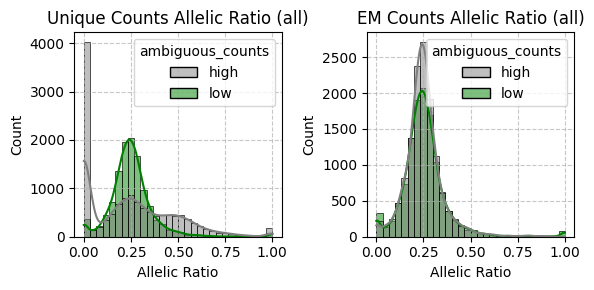

In [89]:
# filter transcripts that are not equal lengths
fig = poly.plot_allelic_ratios(
    adata_isoform_filtered,
    synteny_category="1hap1_1hap2_1hap3_1hap4_s", 
    sample='all', 
    ratio_type="both",
    figsize = (6,3),
    kde = True,
    multimapping_threshold=0.25,
    #save_path="allelic_ratios.svg"
)

You can see that alleles with high expression ratios (>0.8) have big length differences. Therefore we will filter them for the allele expression analysis.

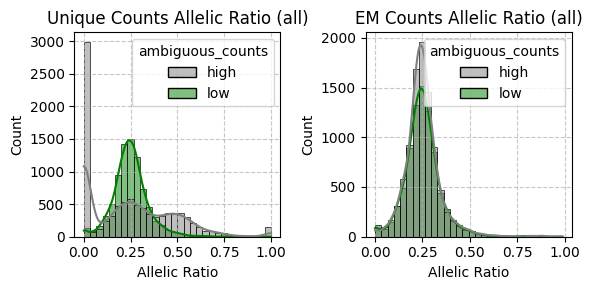

In [ ]:
# filter transcripts that are not equal lengths
mask = adata_isoform_filtered.var["CDS_haplotype_with_longest_annotation"] == "equal_lengths"
adata_isoform_length_filtered = adata_isoform_filtered[:,mask].copy()
fig = poly.plot_allelic_ratios(
    adata_isoform_length_filtered,
    synteny_category="1hap1_1hap2_1hap3_1hap4_s", 
    sample='all', 
    ratio_type="both",
    figsize = (6,3),
    kde = True,
    multimapping_threshold=0.25,
    #save_path="allelic_ratios.svg"
)


After filtering for alleles of equal length, several of the highly biased genes are removed.

Another potential source of bias arises from unequal transcript numbers per gene. For example, a novel transcript may have been identified on only one haplotype. Therefore, we will filter to include only genes where all alleles have the same number of transcripts.

Genes with different transcript numbers across alleles: 293
Genes with equal transcript numbers across alleles: 1739


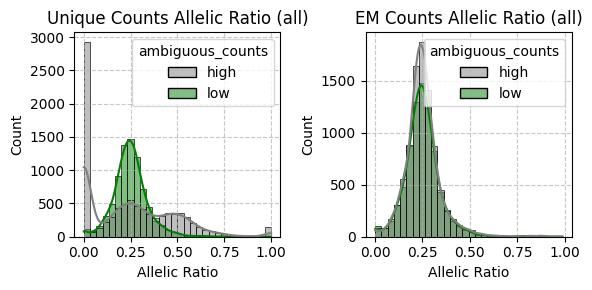

In [47]:
# Group by syntelog ID and check for equal transcript numbers across alleles
synt_ids_same_tx_number = adata_isoform_filtered.var.groupby('Synt_id').aggregate({
    'n_transcripts': set
})

# Count genes with different transcript numbers before filtering
genes_diff_tx_number = synt_ids_same_tx_number[synt_ids_same_tx_number['n_transcripts'].apply(lambda x: len(x) > 1)]
print(f"Genes with different transcript numbers across alleles: {len(genes_diff_tx_number)}")

# Keep only syntelogs where all alleles have the same number of transcripts
synt_ids_same_tx_number = synt_ids_same_tx_number[synt_ids_same_tx_number['n_transcripts'].apply(lambda x: len(x) == 1)]
print(f"Genes with equal transcript numbers across alleles: {len(synt_ids_same_tx_number)}")

# Filter for equal-length transcripts with equal transcript numbers
mask = (adata_isoform_filtered.var["CDS_haplotype_with_longest_annotation"] == "equal_lengths") & \
       (adata_isoform_filtered.var['Synt_id'].isin(synt_ids_same_tx_number.index))



adata_isoform_length_filtered = adata_isoform_filtered[:, mask].copy()

# Plot allelic ratios after filtering
fig = poly.plot_allelic_ratios(
    adata_isoform_length_filtered,
    synteny_category="1hap1_1hap2_1hap3_1hap4_s",
    sample='all',
    ratio_type="both",
    figsize=(6, 3),
    kde=True,
    multimapping_threshold=0.25,
    #save_path="allelic_ratios.svg"
)

Try out different filtering thresholds and strategies to find the optimal balance between removing false positives and retaining true biological signals.
In cases where the haplotypes or subgenomes are more different the treshold should not have a big effect.

Now there are less alleles with ratios around 0 and >0.8.

### A) Cis: Testing for differential allelic expression

We will test within one condition (here: 'leaf'), wether there are genes where alleles have unbalanced expression.

In [48]:
# select only the genes with equal lengths, low multimapping ratio and synteny category "1hap1_1hap2_1hap3_1hap4_s"
mask = (adata_gene_filtered.var["multimapping_ratio"] < 0.25) & (adata_gene_filtered.var["synteny_category"] == "1hap1_1hap2_1hap3_1hap4_s")& (adata_gene_filtered.var["CDS_haplotype_with_longest_annotation"] == "equal_lengths") & (adata_gene_filtered.var['Synt_id'].isin(synt_ids_same_tx_number.index))
adata_gene_length_filter = adata_gene_filtered[:,mask].copy()

# Test for differential allelic ratios withing conditions
cis_results_control = poly.test_allelic_ratios_within_conditions(adata_gene_length_filter, 
                                                                 layer="unique_counts", 
                                                                 test_condition= "leaf", 
                                                                 inplace=True)
# Get top differential syntelogs
cis_top_results = poly.get_top_differential_syntelogs(cis_results_control, 
                                                      n=45, sort_by='ratio_difference',
                                                      fdr_threshold=0.05, 
                                                      ratio_threshold=0.1)

Using CPM data from layer: unique_cpm
Processing syntelog 100/199
Found 56 from 199 syntelogs with at least one significantly different allele (FDR < 0.05 and ratio difference > 0.1)


#### Plotting of overall allelic expression ratios

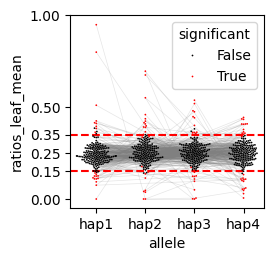

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


cis_results_control['significant'] = (cis_results_control['p_value'] < 0.05) & (cis_results_control['ratio_difference'] > 0.1)

# Add a temporary column to track original order
cis_results_control['plot_order'] = range(len(cis_results_control))
# set the colors for significant and non-significant points
palette = {True: 'red', False: 'black'}
# Create the swarm plot
fig, ax = plt.subplots(figsize=(2.5, 2.5))
sns.swarmplot(y=cis_results_control['ratios_leaf_mean'], 
              x=cis_results_control['allele'], 
              hue=cis_results_control['significant'], 
              size=1.25,
              ax=ax,
              palette=palette,
              order=['hap1', 'hap2', 'hap3', 'hap4'])

# Extract point positions from the plot
points_data = []
for collection in ax.collections:
    offsets = collection.get_offsets().data
    for x, y in offsets:
        points_data.append({'x': x, 'y': y})

# Match points to data by y-values (within tolerance)
point_positions = {}
for idx, row in cis_results_control.iterrows():
    y_val = row['ratios_leaf_mean']
    allele_idx = ['hap1', 'hap2', 'hap3', 'hap4'].index(row['allele'])
    
    # Find matching point (closest in y-value near the correct x position)
    for point in points_data:
        if abs(point['y'] - y_val) < 0.001 and abs(point['x'] - allele_idx) < 0.5:
            if idx not in point_positions:
                point_positions[idx] = (point['x'], point['y'])
                break

# Connect paired points by Synt_id
for synt_id in cis_results_control['Synt_id'].unique():
    subset = cis_results_control[cis_results_control['Synt_id'] == synt_id]
    if len(subset) >= 2:  # Connect all points with same Synt_id
        indices = subset.index.tolist()
        valid_indices = [i for i in indices if i in point_positions]
        
        if len(valid_indices) >= 2:
            for i in range(len(valid_indices) - 1):
                x_vals = [point_positions[valid_indices[i]][0], point_positions[valid_indices[i+1]][0]]
                y_vals = [point_positions[valid_indices[i]][1], point_positions[valid_indices[i+1]][1]]
                ax.plot(x_vals, y_vals, color='gray', linewidth=0.5, alpha=0.2, zorder=0)

plt.yticks([0.0, 0.15, 0.25, 0.35, 0.5, 1.0])
plt.axhline(y=0.35, color='r', linestyle='--')
plt.axhline(y=0.15, color='r', linestyle='--')

plt.show()

#### Plot the results for the genes with large differences in allelic expression

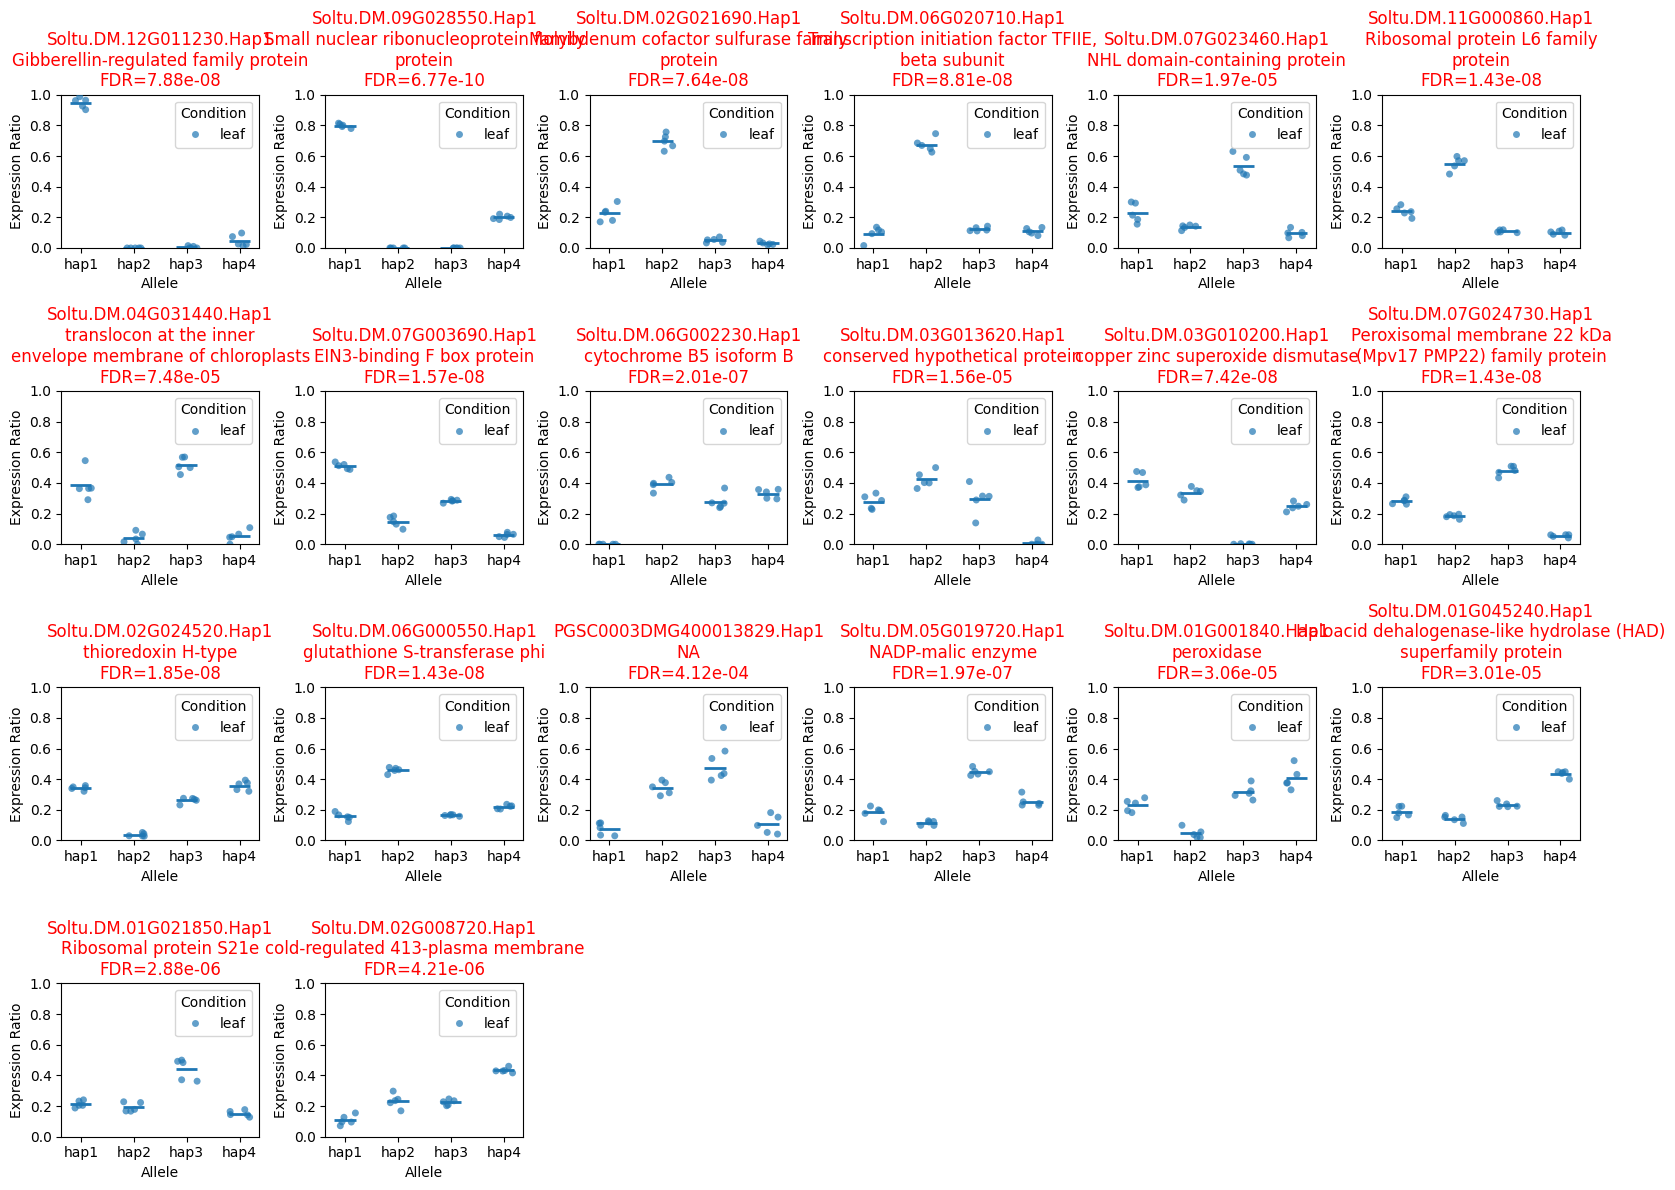

In [50]:

fig = poly.plot_top_differential_syntelogs(cis_top_results, 
                                           n = 20, 
                                           sort_by='ratio_difference')

#### Plot ratios and CPM for one particular gene

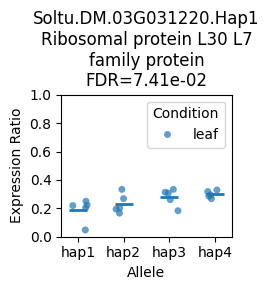

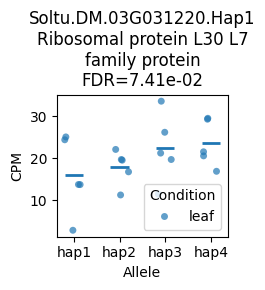

In [51]:
gene_id = "Soltu.DM.03G031220"

# filter results for specific synt id
cis_results_filtered_synt = cis_results_control[cis_results_control['gene_id'].str.contains(gene_id)]
ax1 = poly.plot_top_differential_syntelogs(cis_results_filtered_synt, n = 20, figsize = (12, 3),sort_by='ratio_difference')

# filter results for specific synt id
cis_results_filtered_synt = cis_results_control[cis_results_control['gene_id'].str.contains(gene_id)]
ax2 = poly.plot_top_differential_syntelogs(cis_results_filtered_synt, n = 20, figsize = (12, 3*1),sort_by='ratio_difference', plot_type='cpm' )

#### We can also look at genes where all alles have balanced expression 

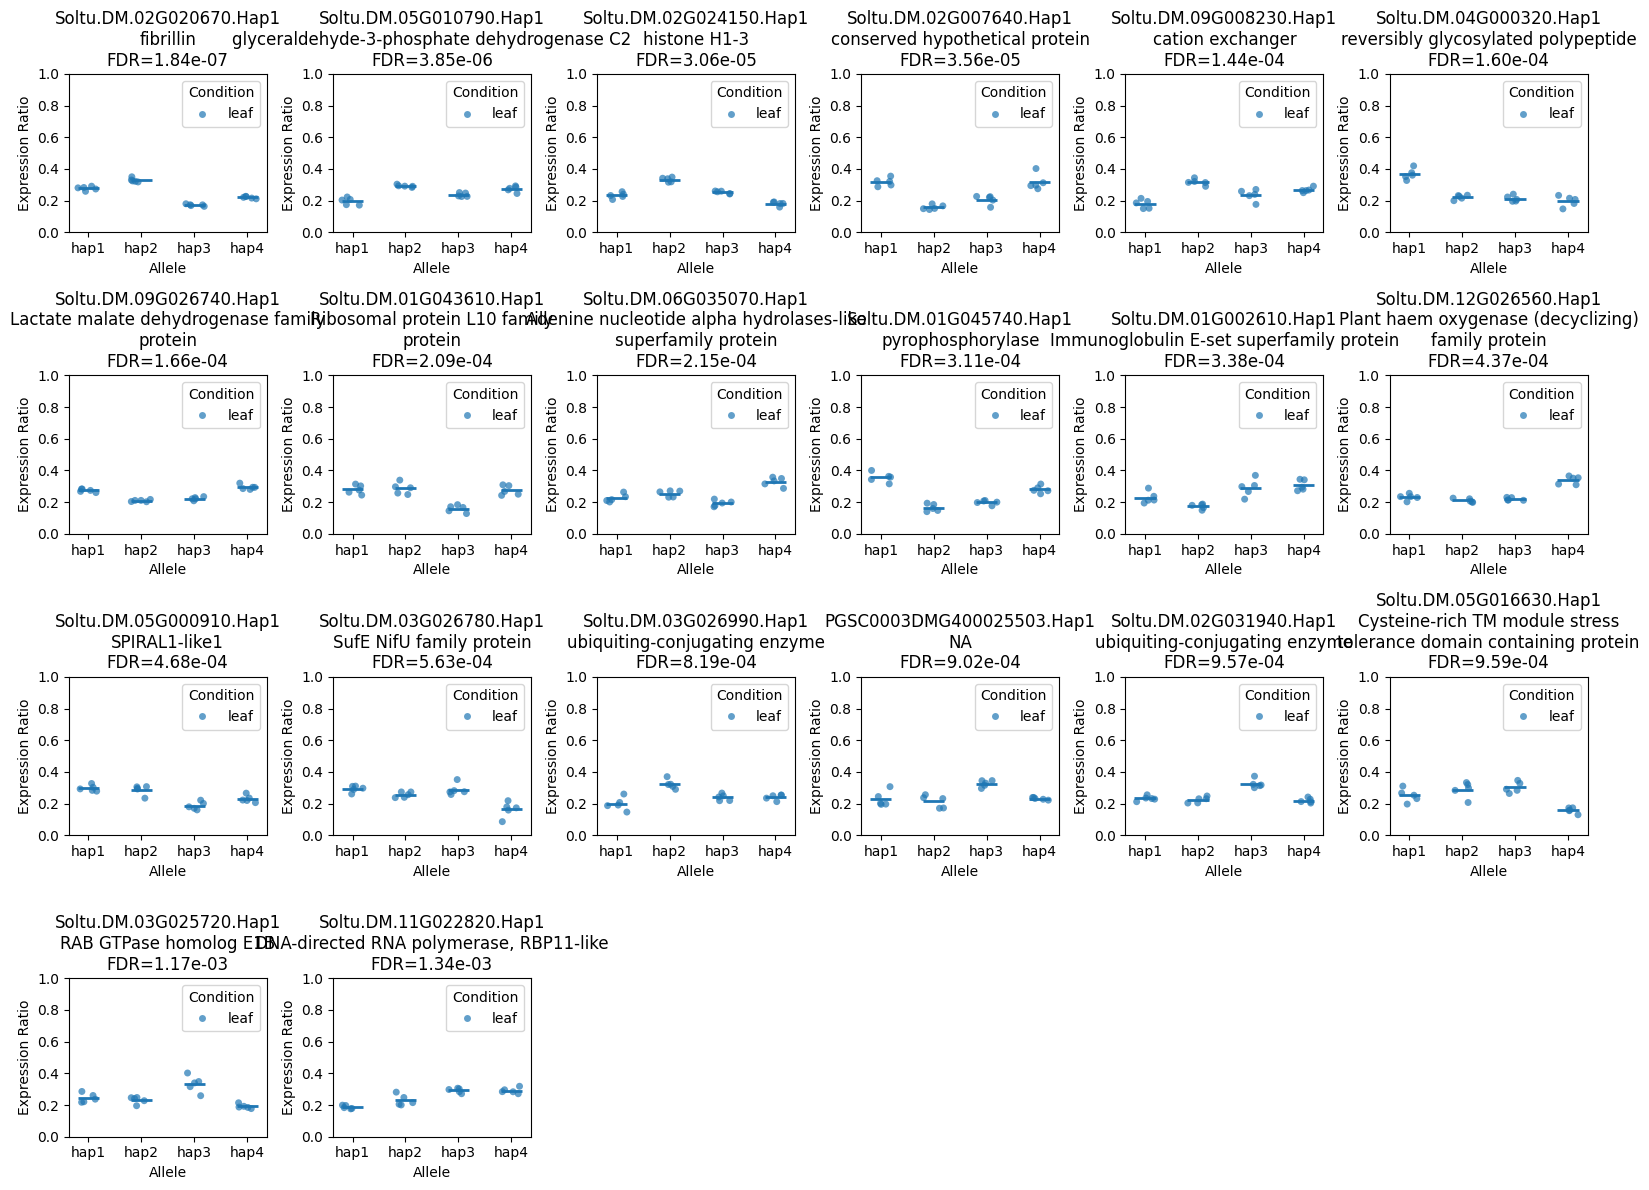

In [52]:
grouped_results= cis_results_control.groupby('Synt_id').agg({
    'FDR': 'min',
    'ratio_difference': 'max' , # Assuming this is the correct column name
    'gene_id': 'first'  # Concatenate gene IDs
        })
# split the last prefix from transcript_id
grouped_results['gene_id'] = grouped_results['gene_id'].apply(lambda x: x.rsplit('.', 1)[0] if isinstance(x, str) else x)
    # Print summary
significant_results = grouped_results[(grouped_results['FDR'] < 0.05) & (grouped_results['ratio_difference'] > 0.1)]

unsignificant_results = grouped_results[(grouped_results['FDR'] >= 0.05) | (grouped_results['ratio_difference'] <= 0.1)]

# Filter the syntelog results with balanced expression for plotting
mask = unsignificant_results.index
balanced_cis_results = cis_results_control[cis_results_control['Synt_id'].isin(unsignificant_results.index)]
fig = poly.plot_top_differential_syntelogs(balanced_cis_results, 
                                           n = 20)


### B) Trans: Testing for differences in allelic expression between conditions

Now we only filter of syntenic group, as multimapping and difference in transcript length should not bias the results when comparing conditions

In [53]:
# Filter to only include synteny category "1hap1_1hap2_1hap3_1hap4_s" 
mask = (adata_isoform_filtered.var["synteny_category"] == "1hap1_1hap2_1hap3_1hap4_s")
adata_gene_syntelogs = adata_gene_filtered[:,mask].copy()

Using CPM data from layer: unique_cpm
Processing syntelog 100/629
Processing syntelog 200/629
Processing syntelog 300/629
Processing syntelog 400/629
Processing syntelog 500/629
Processing syntelog 600/629
Found 156 from 624 syntelogs with at least one significantly different allele (FDR < 0.05 and ratio difference > 0.1)


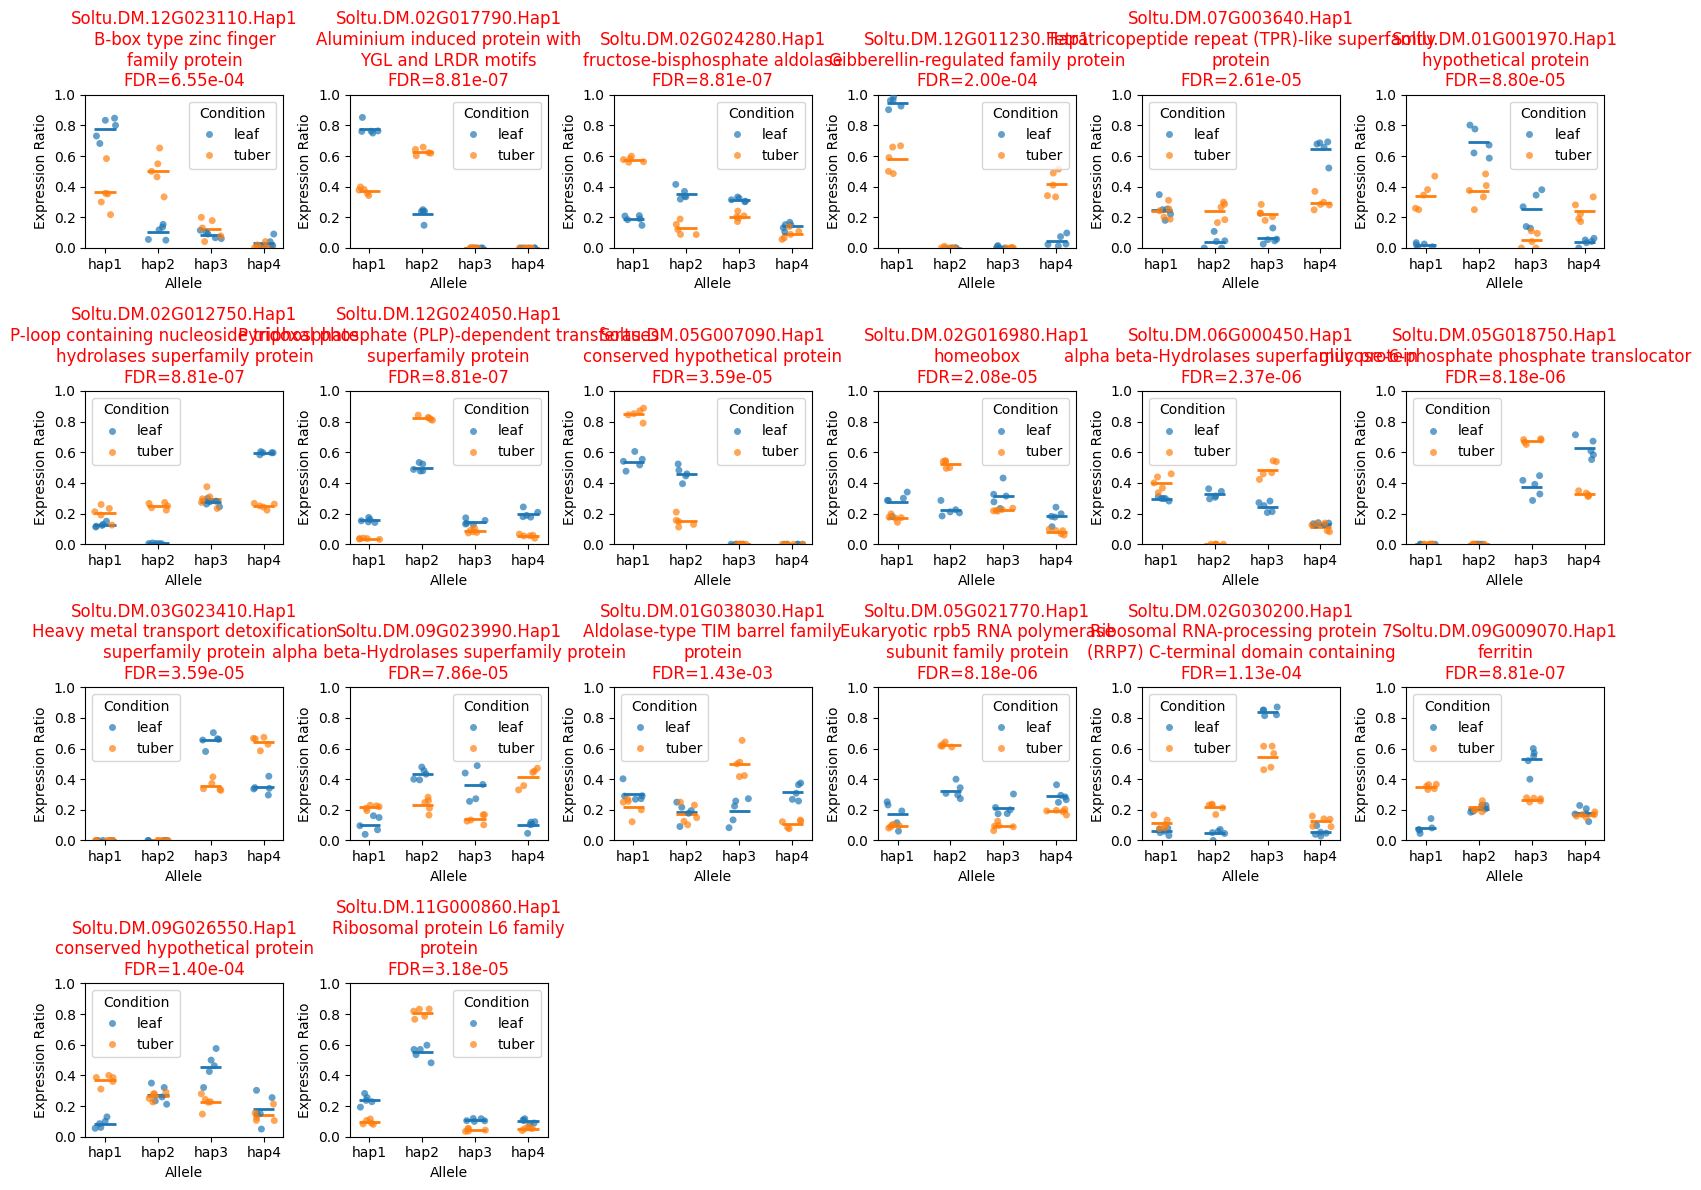

In [54]:
# Run allelic ratio test
results_df_trans = poly.test_allelic_ratios_between_conditions(adata_gene_syntelogs)

# Get top differential syntelogs
top_results_trans = poly.get_top_differential_syntelogs(results_df_trans, n=50, sort_by='ratio_difference', fdr_threshold=0.05)

# Plot the results
fig = poly.plot_top_differential_syntelogs(top_results_trans, 
                                           n = 20, 
                                           ratio_difference_threshold=0.1, 
                                           sort_by='ratio_difference', 
                                           sig_threshold=0.05)

#### Plot Ribosomal protein L3 as example 

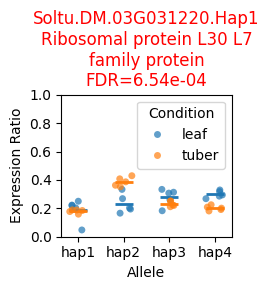

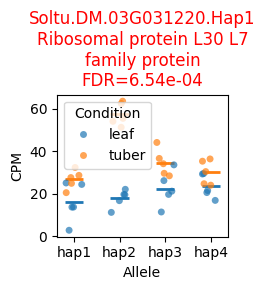

In [55]:
gene_id = "Soltu.DM.03G031220"

# filter results for specific synt id
trans_results_filtered_synt = results_df_trans[results_df_trans['gene_id'].str.contains(gene_id)]
ax1 = poly.plot_top_differential_syntelogs(trans_results_filtered_synt, n = 20, figsize = (12, 3*1),sort_by='ratio_difference' )

ax2 = poly.plot_top_differential_syntelogs(trans_results_filtered_synt, n = 20, figsize = (12, 3*1),sort_by='ratio_difference', plot_type='cpm' )

##### Plot vacuolar ATP synthase subunit A

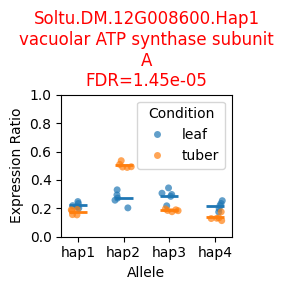

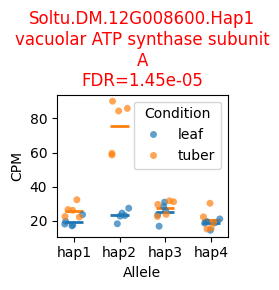

In [56]:
gene_id = "Soltu.DM.12G008600"

# filter results for specific synt id
trans_results_filtered_synt = results_df_trans[results_df_trans['gene_id'].str.contains(gene_id)]
ax1 = poly.plot_top_differential_syntelogs(trans_results_filtered_synt, n = 20, figsize = (12, 3*1),sort_by='ratio_difference')

ax2 = poly.plot_top_differential_syntelogs(trans_results_filtered_synt, n = 20, figsize = (12, 3*1),sort_by='ratio_difference', plot_type='cpm' )

In [57]:
top_results_trans['Unitato_gene_id'] = top_results_trans['gene_id'].apply(lambda x: x.rsplit('.', 1)[0] if isinstance(x, str) else x)
# group by Synt_id and get the min FDR and max ratio_difference
top_results_trans_grouped = top_results_trans.groupby('Synt_id').agg({
    'FDR': 'min',
    'ratio_difference': list , # Assuming this is the correct
    'allele' : list,
    'gene_id': list,
    'Unitato_gene_id': 'first'  # Get unique gene IDs

})
# save the results to a tsv
# top_results_trans_grouped.to_csv()

/tmp/ipykernel_1617059/3657271931.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## 3) Isoform level analysis

In the previous steps we tested for differences in in allelic expression on gene level, no we are looking at the isoform level

##### Filtering out genes with low expression

In [58]:
adata_isoform_filtered = poly.filter_low_expressed_genes(
    adata_isoform,
    min_expression=20.0,  # 20 counts
    mode= 'all',
    group_col = 'gene_id',
    layer = 'em_counts',
    verbose=True)

Using uniform threshold: 20.0
Filtered out 198379 groups
Kept 5462 / 250224 items


In [59]:
adata_isoform_filtered = poly.calculate_allelic_ratios(adata_isoform_filtered, 'unique_counts' )
adata_isoform_filtered = poly.calculate_multi_ratios(adata_isoform_filtered, 'unique_counts', 'ambiguous_counts')
adata_isoform_filtered = poly.calculate_per_allele_ratios(adata_isoform_filtered, unique_layer='unique_counts', multi_layer='ambiguous_counts')

### C) Testing for differential isoform usage between conditions

Now we are testing for differential isofrom usage (DIU). Are there different isoforms expressed in tuber than in leaves?

In [60]:
# select only the genes with equal lengths, low multimapping ratio and synteny category "1hap1_1hap2_1hap3_1hap4_s"
mask =  (adata_isoform_filtered.var["tx_multimapping_ratio_per_allele_weighted_average"] < 0.25)
adata_isoform_multimapping_filter = adata_isoform_filtered[:,mask].copy()

# Test for differential allelic ratios withing conditions
DIU_results, DIU_plotting_result = poly.test_isoform_DIU_between_conditions(adata_isoform_multimapping_filter, 
                                                                       layer="unique_counts", 
                                                                       inplace=True)

Calculating isoform ratios...
Processing gene 100/1449
Processing gene 200/1449
Processing gene 300/1449
Processing gene 400/1449
Processing gene 500/1449
Processing gene 600/1449
Processing gene 700/1449
Processing gene 800/1449
Processing gene 900/1449
Processing gene 1000/1449
Processing gene 1100/1449
Processing gene 1200/1449
Processing gene 1300/1449
Processing gene 1400/1449
Found 6 from 165 genes with at least one significantly different isoform (FDR < 0.05 and ratio difference > 0.2)
Skipped 163 isoforms due to zero counts
Created plotting table with 1950 rows (one per replicate, condition, isoform ratio, and transcript)


For plotting of differential isoform usage we also need to add the gene structure from the gtf files.

In [61]:
# we use the original unitato annotations as they contain CDS information
ensembl_gtf_path = f"{input_dir}/unitato2Atl.with_chloroplast_and_mito.no_scaffold.agat.gtf"
annotation = RNApy.read_ensembl_gtf(ensembl_gtf_path)

# add the bambu annotations to the annotation dataframe to also include novel iosforms and genes
bambu = f"{input_dir}/combined.fixed.gtf"
bambu_annotation = RNApy.read_ensembl_gtf(bambu)
bambu_annotation = bambu_annotation.filter(pl.col("transcript_id").str.contains("Bambu"))


annotation.extend(bambu_annotation)
annotation_df = annotation.to_pandas()
annotation_df['gene_id_unitato'] = annotation_df['gene_id'].str.rsplit('.', n=1).str[0]

# back to polar
annotation_pl = pl.from_pandas(annotation_df)

In [62]:
figures = poly.plot_differential_isoform_usage(
    results_df=DIU_plotting_result,
    annotation_df=annotation_pl,
    fdr_threshold=0.05,
    ratio_difference_threshold=0.2
)

Detected layer: unique_counts (using column: unique_counts_cpm)
Found 6 genes with significant isoforms. Plotting all isoforms for these genes.
Processing gene: PGSC0003DMG400011125.Hap2


Processing gene: Soltu.DM.03G037260.Hap0
Skipping Soltu.DM.03G037260.Hap0 as it has only one transcript
Processing gene: Soltu.DM.06G029200.Hap4


/users/nadjafn/.conda/envs/polyase/lib/python3.12/site-packages/RNApysoforms/gene_filtering.py:168: UserWarning:

2 transcript(s) are present in the annotation but missing in the expression matrix. Missing transcripts: Soltu.DM.06G029200.3.Hap4, Soltu.DM.06G029200.4.Hap4. Only transcripts present in both will be returned.



Processing gene: Soltu.DM.09G025500.Hap4


Processing gene: Soltu.DM.10G027570.Hap2


Processing gene: Soltu.DM.12G003180.Hap0


Generated 5 plots for differential isoform usage


### D) Testing for differential isofrom strucuture between haplotypes


Now we will test if there are any genes that have a different isoform expressed on the different haplotypes. This can be caused for instance by mutations in splice sites.

In [63]:
adata_isoform_filtered = poly.filter_low_expressed_genes(
    adata_isoform[adata_isoform.obs['condition'] == 'leaf',: ],
    min_expression=20.0,  # 20 counts
    mode= 'all',
    layer = 'em_counts',
    group_col = 'Synt_id',
    verbose=True)

Using uniform threshold: 20.0
Filtered out 84105 groups
Kept 30295 / 250224 items


In [64]:
#First add exon structure information to your AnnData object
gtf_file = bambu

# Add structure information (this can take some time)
poly.add_structure_from_gtf(adata_isoform_filtered, 
                            gtf_file, 
                            inplace=True, 
                            verbose=True)

Loading GTF file: /scratch/nadjafn/LR_DESIREE_PAPER/zenodo//polyase_tutorial_atlantic/combined.fixed.gtf
Processing exon structures...
Processed 250224 transcripts
Exon count distribution:
n_exons
1     70765
2     53581
3     32202
4     19639
5     14515
6     11146
7      9139
8      7440
9      6317
10     5105
Name: count, dtype: int64
Calculated introns for 179459 multi-exon transcripts
Intron count distribution:
n_introns
1     53581
2     32202
3     19639
4     14515
5     11146
6      9139
7      7440
8      6317
9      5105
10     3976
Name: count, dtype: int64
Adding structure information to AnnData.var...
Matched structure information for 30295/30295 transcripts
Successfully added exon structure information for 250224 transcripts
  - Intron structures calculated for multi-exon transcripts


In [65]:
adata_isoform_filtered = poly.calculate_allelic_ratios(adata_isoform_filtered, 'unique_counts' )
adata_isoform_filtered = poly.calculate_multi_ratios(adata_isoform_filtered, 'unique_counts', 'ambiguous_counts')
adata_isoform_filtered = poly.calculate_per_allele_ratios(adata_isoform_filtered, unique_layer='unique_counts', multi_layer='ambiguous_counts')

In [66]:
mask =(adata_isoform_filtered.var["tx_multimapping_ratio_per_allele_weighted_average"] < 0.3) & \
      (adata_isoform_filtered.var["synteny_category"] == "1hap1_1hap2_1hap3_1hap4_s")

#mask = adata_isoform_filtered.var["Synt_id"] == "Synt_id_59067"
adata_isoform_multimapping_filtered = adata_isoform_filtered[:,mask].copy()


#  Run structure-based DIU analysis
results_DIU_allele, results_DIU_plotting = poly.test_differential_isoform_structure(
    adata_isoform_multimapping_filtered, 
    layer="em_counts",
    test_condition="all",  # or "all" to use all conditions
    min_similarity_for_matching=0.8,
    inplace=True
)

DEBUG: Found 5 samples for condition 'all'
DEBUG: Found 1051 syntelogs to process

DEBUG Syntelog Synt_id_44039: 2 haplotypes, 2 transcripts
DEBUG: Haplotype expressions: {'hap1': np.float64(1357.0253625561093), 'hap3': np.float64(1201.9826994340442)}
DEBUG: Selected reference haplotype: hap1 (expression=1357.0253625561093)
DEBUG: Reference haplotype hap1 has 1 isoforms
  Soltu.DM.07G022140.1.Hap1: expression=1357.0253625561093
  hap3: Matched to MAJOR (Soltu.DM.07G022140.1.Hap3, sim=0.998)
DEBUG: Found 2 haplotype matches
DEBUG: Major on all haplotypes: True
DEBUG: Testing using MAJOR isoform
DEBUG: Reference counts: [ 44.71092981 265.54251505 529.06144914], totals: [ 44.71092981 265.54251505 529.06144914]

DEBUG Syntelog Synt_id_24575: 2 haplotypes, 2 transcripts
DEBUG: Haplotype expressions: {'hap3': np.float64(161.4884748352603), 'hap4': np.float64(85.0767614370324)}
DEBUG: Selected reference haplotype: hap3 (expression=161.4884748352603)
DEBUG: Reference haplotype hap3 has 1 isofo

In [67]:
fig = poly.plot_allele_specific_isoform_structure(results_DIU_plotting[results_DIU_plotting['gene_id'].str.contains("Soltu.DM.11G023050")],
                                                  annotation_df = annotation_pl, 
                                                  ratio_difference_threshold=0.2)

Detected layer: isoform (using column: isoform_cpm)
Found 1 syntelogs with significant allelic differences. Plotting all isoforms for these syntelogs.
Processing Synt_id: Synt_id_59067
Gene: Soltu.DM.11G023050.Hap3


Generated 1 plots for allele-specific isoform structure


In [68]:
fig = poly.plot_allele_specific_isoform_structure(results_DIU_plotting,
                                                  annotation_df = annotation_pl, 
                                                  ratio_difference_threshold=0.2)

Detected layer: isoform (using column: isoform_cpm)
Found 7 syntelogs with significant allelic differences. Plotting all isoforms for these syntelogs.
Processing Synt_id: Synt_id_59067
Gene: Soltu.DM.11G023050.Hap3


Processing Synt_id: Synt_id_15269
Gene: Soltu.DM.01G048050.Hap3


Processing Synt_id: Synt_id_43794
Gene: Soltu.DM.07G020120.Hap2


Processing Synt_id: Synt_id_19637
Gene: Soltu.DM.02G024920.Hap4


Processing Synt_id: Synt_id_30815
Gene: Soltu.DM.05G002340.Hap3


Processing Synt_id: Synt_id_38611
Gene: Soltu.DM.06G021330.Hap4


Processing Synt_id: Synt_id_15748
Gene: Soltu.DM.02G000560.Hap4


Generated 7 plots for allele-specific isoform structure


### E) Vizualization of alignments

To exlude false positive results it is essential to also look at the alignments in a genome browser. We recoomend jBrowse2 as this allows to open several chromosomes at the same time. So we can view the haplotypes all at once.
The downsampled reads with haplotype tags are in 'longrnaseq/output/haplotag/*bam'.

You can color and sort the aligned reads by the `HP` tag.

This are the alignments of a gene with difference in isoform strucure due to a splice site mutation:

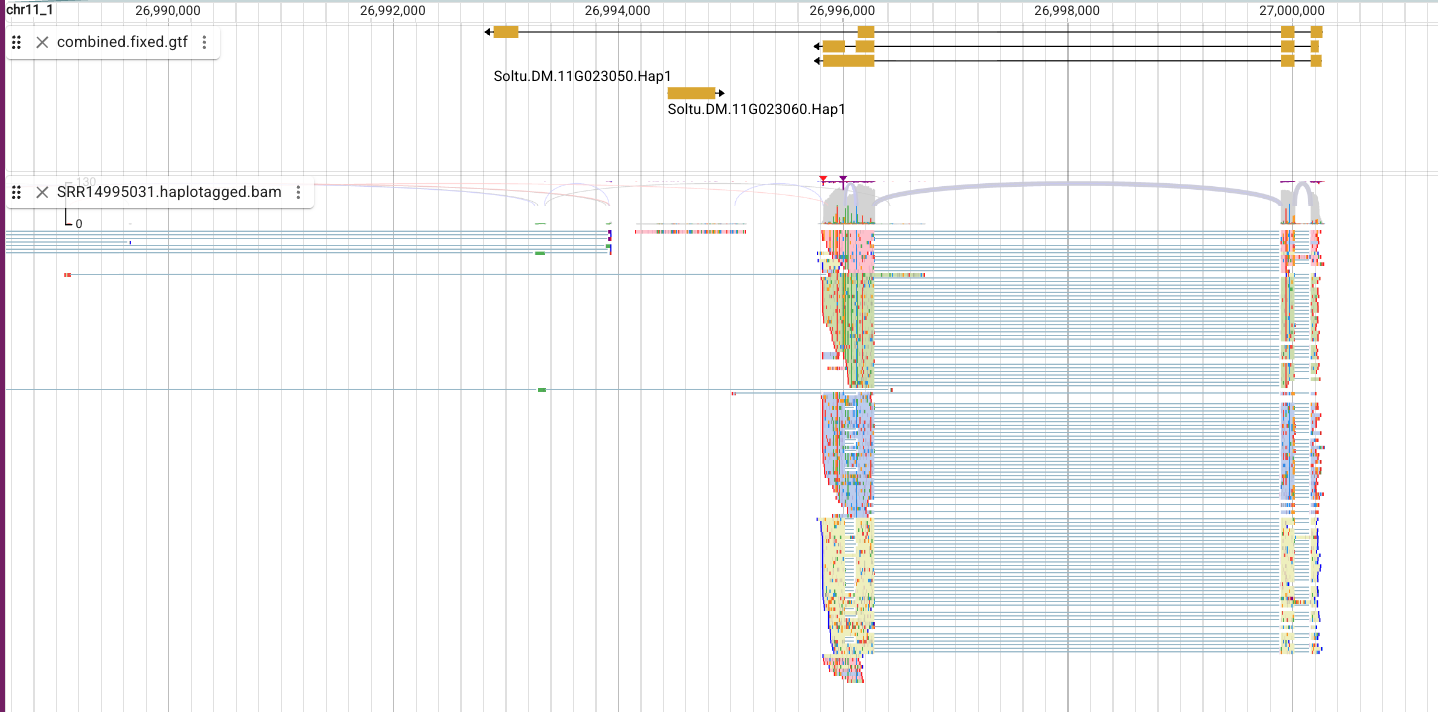